Loading d:\PaperWork\personal\AI\LLM_Engg_GenAI_Rag_Lora_Agent\personal_works\MS\Driver\carla_0_9\CARLA_0.9.15\WindowsNoEditor\PythonAPI\carla-python-examples-main\Map_Layouts\lane_change_dataset.csv...
Found 350 total episodes.


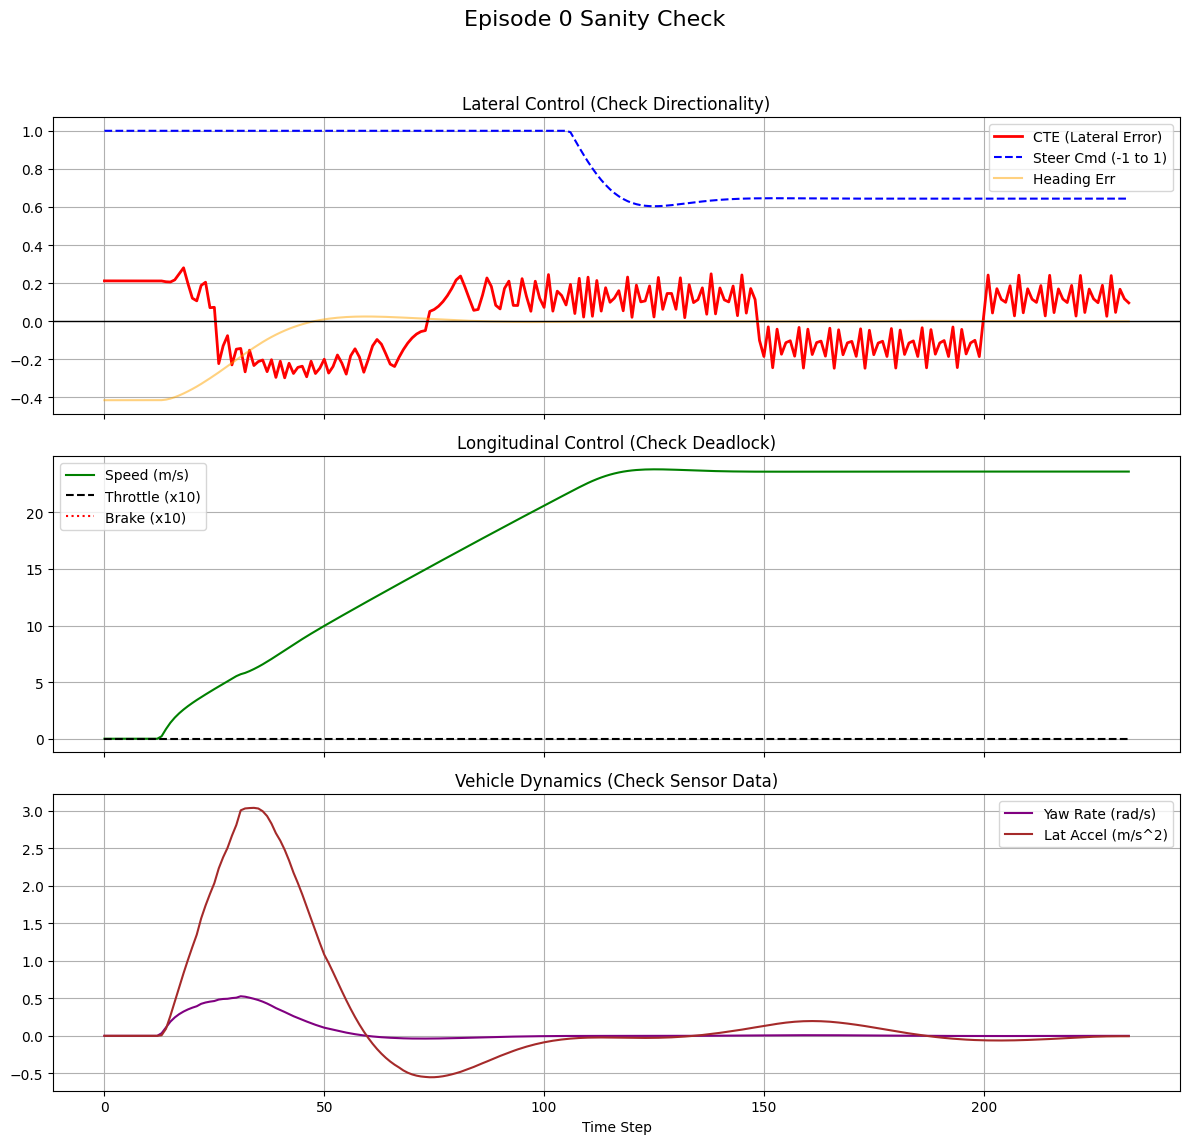

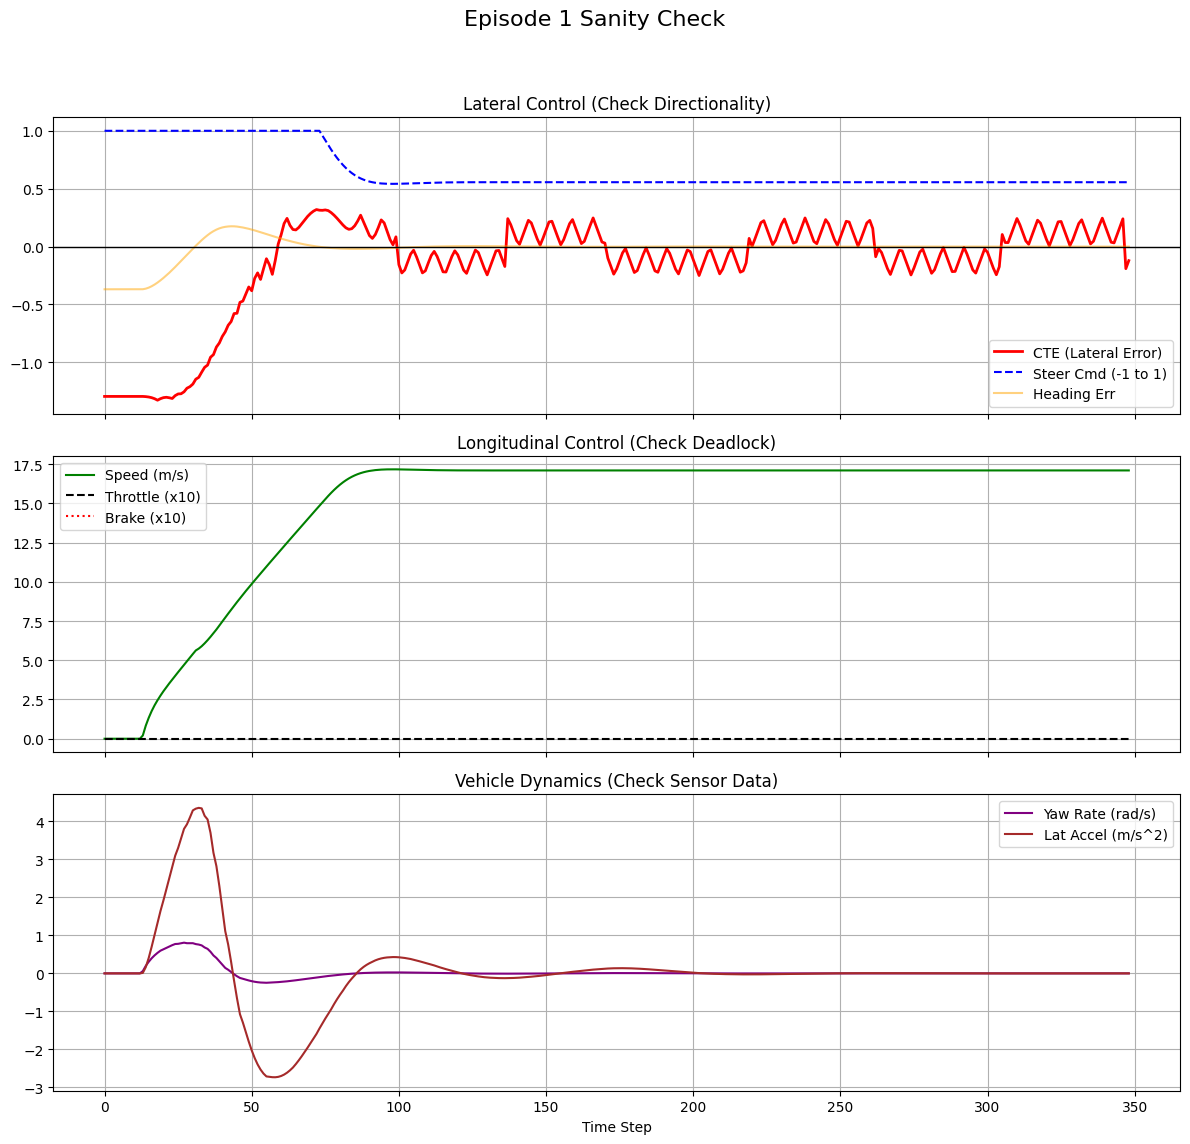

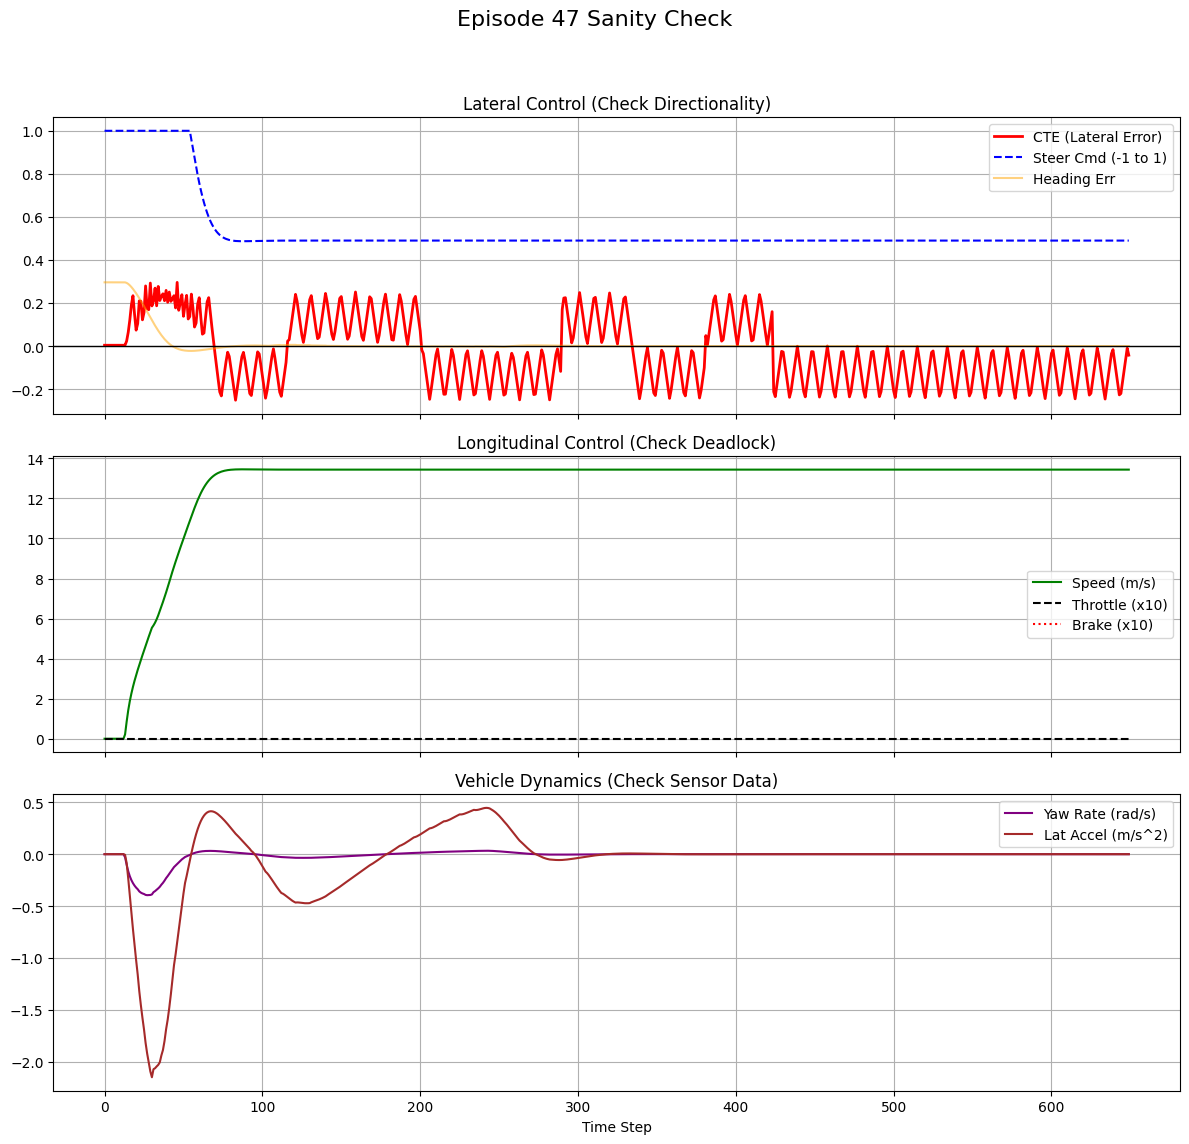

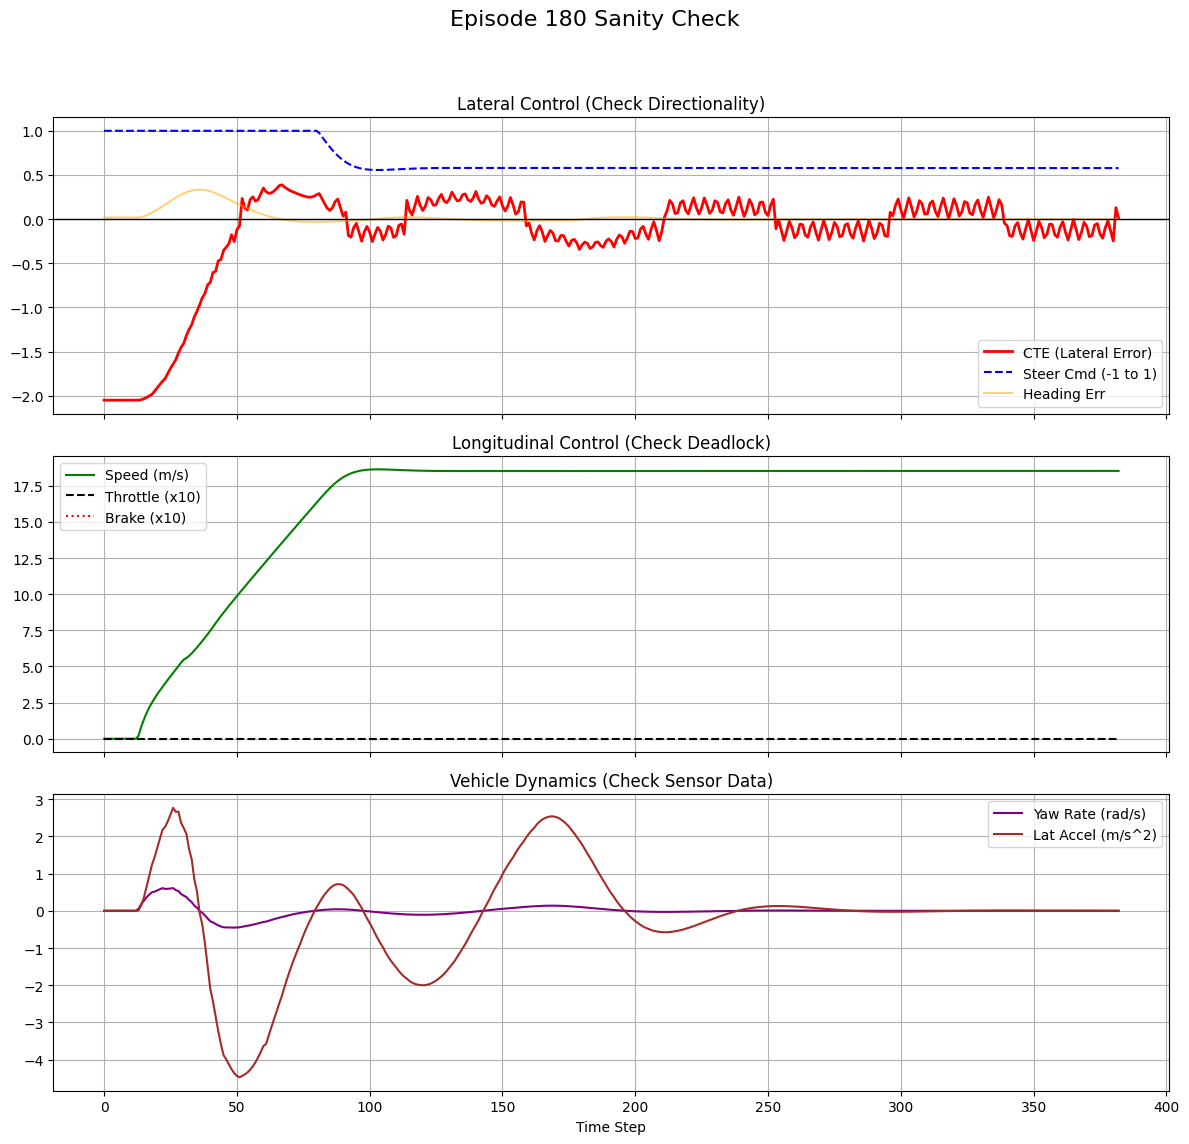

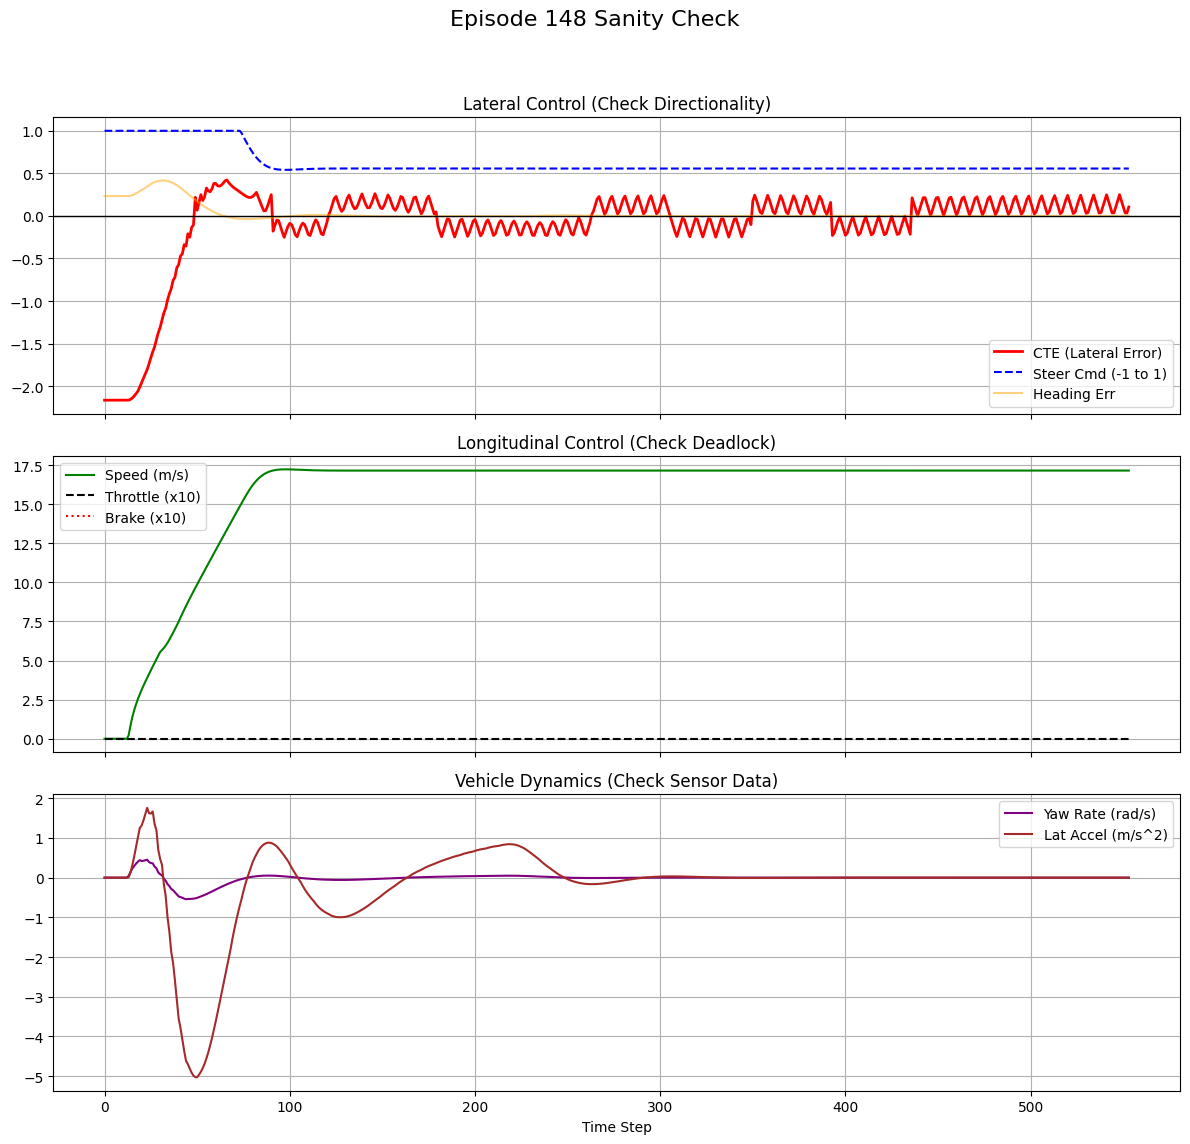

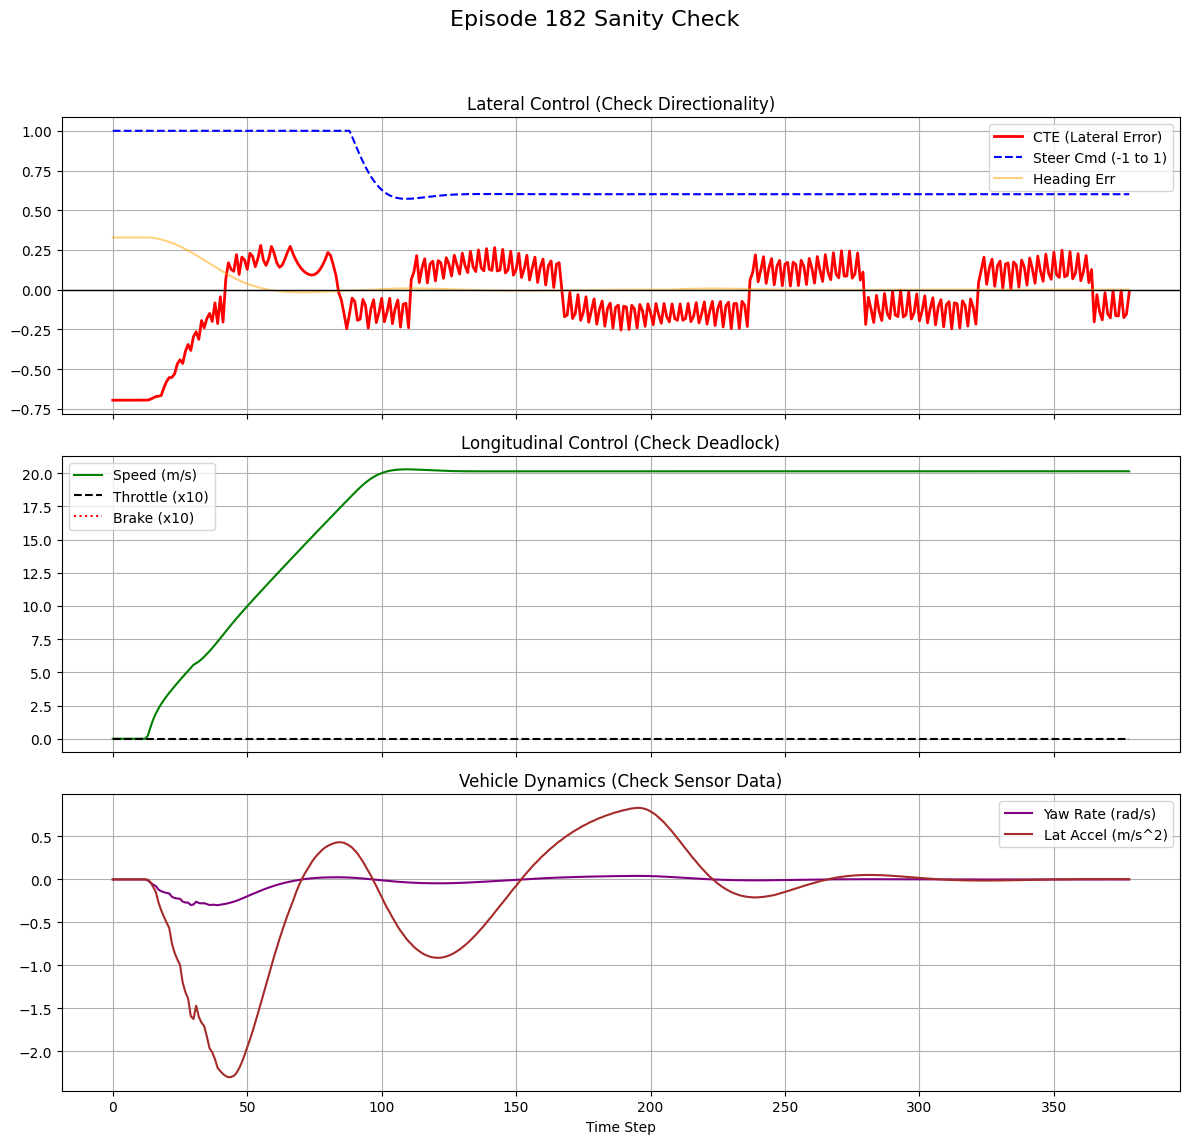

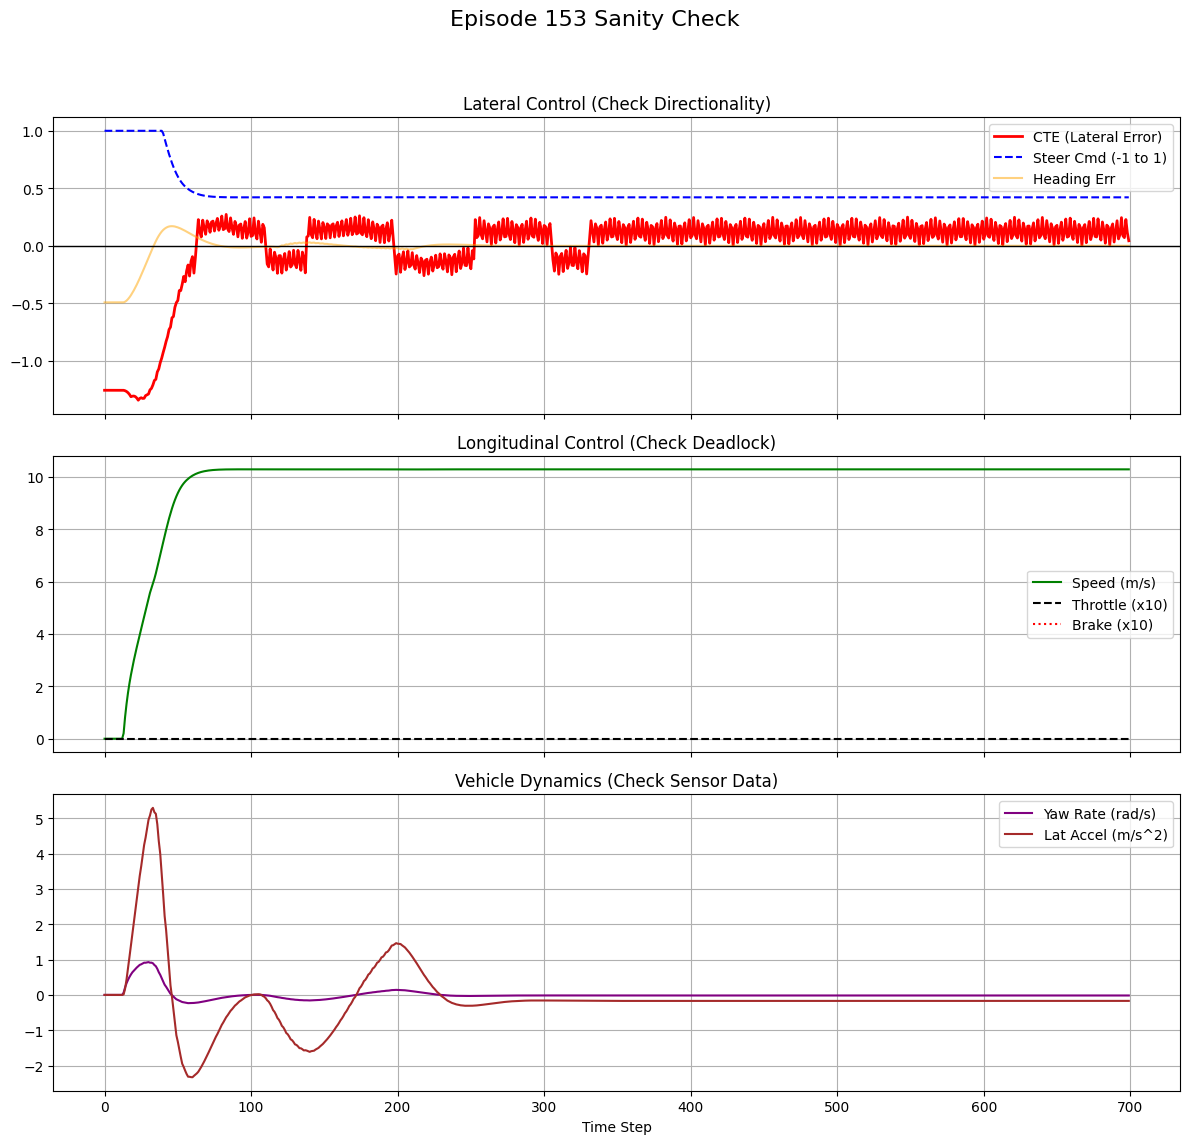

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os

# --- CONFIGURATION ---
current_dir = Path(os.getcwd())

CSV_FILE =  current_dir.parent / "Map_Layouts" / "lane_change_dataset.csv"
NUM_EPISODES_TO_PLOT = 5  # How many random episodes to check

def plot_data(csv_path):
    print(f"Loading {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("CSV file not found.")
        return

    # Get unique episodes
    if 'episode_id' not in df.columns:
        print("Error: 'episode_id' column missing. Cannot group data.")
        return

    unique_episodes = df['episode_id'].unique()
    print(f"Found {len(unique_episodes)} total episodes.")

    # Pick random episodes to inspect
    # We take a few from the start and a few random ones to ensure variety
    selected_ids = unique_episodes[:2] # First 2
    if len(unique_episodes) > 5:
        random_ids = np.random.choice(unique_episodes[2:], NUM_EPISODES_TO_PLOT, replace=False)
        selected_ids = np.concatenate((selected_ids, random_ids))

    for ep_id in selected_ids:
        # Filter data for this episode
        data = df[df['episode_id'] == ep_id].reset_index(drop=True)
        time_steps = data.index

        # Create a figure with 3 Subplots (Lateral, Longitudinal, Physics)
        fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
        fig.suptitle(f"Episode {int(ep_id)} Sanity Check", fontsize=16)

        # --- SUBPLOT 1: LATERAL CONTROL (Steer vs Error) ---
        # CHECK: Does Steer react opposite to CTE? (e.g., CTE + means Steer -)
        ax1 = axes[0]
        ax1.set_title("Lateral Control (Check Directionality)")
        ax1.plot(time_steps, data['cte_input'], label='CTE (Lateral Error)', color='red', linewidth=2)
        
        # Scale steer up for visibility (Steer is -1 to 1, CTE can be meters)
        ax1.plot(time_steps, data['steer_cmd'], label='Steer Cmd (-1 to 1)', color='blue', linestyle='--')
        
        # Also plot Heading Error to see alignment
        if 'heading_error_input' in data.columns:
            ax1.plot(time_steps, data['heading_error_input'], label='Heading Err', color='orange', alpha=0.5)
            
        ax1.axhline(0, color='black', linewidth=1)
        ax1.legend()
        ax1.grid(True)

        # --- SUBPLOT 2: LONGITUDINAL CONTROL (Speed vs Throttle) ---
        # CHECK: Does Throttle stay > 0 when Speed < Target?
        ax2 = axes[1]
        ax2.set_title("Longitudinal Control (Check Deadlock)")
        ax2.plot(time_steps, data['speed_input'], label='Speed (m/s)', color='green')
        
        # Plot Target Speed if available
        if 'target_speed_input' in data.columns:
            ax2.plot(time_steps, data['target_speed_input'], label='Target (m/s)', color='lightgreen', linestyle=':')
        
        # Plot Throttle/Brake on secondary axis scale or just normalized
        ax2.plot(time_steps, data['throttle_cmd'] * 10, label='Throttle (x10)', color='black', linestyle='--')
        ax2.plot(time_steps, data['brake_cmd'] * 10, label='Brake (x10)', color='red', linestyle=':')
        
        ax2.legend()
        ax2.grid(True)

        # --- SUBPLOT 3: DYNAMICS (IMU Inputs) ---
        # CHECK: Are these flat lines at 0? If so, inputs are broken.
        ax3 = axes[2]
        ax3.set_title("Vehicle Dynamics (Check Sensor Data)")
        
        if 'yaw_rate_input' in data.columns:
            ax3.plot(time_steps, data['yaw_rate_input'], label='Yaw Rate (rad/s)', color='purple')
        
        if 'lat_accel_input' in data.columns:
            ax3.plot(time_steps, data['lat_accel_input'], label='Lat Accel (m/s^2)', color='brown')
            
        ax3.legend()
        ax3.grid(True)
        ax3.set_xlabel("Time Step")

        # Layout fix
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

if __name__ == "__main__":
    plot_data(CSV_FILE)